# Dataset 2: Prediksi Konsumsi Energi Bangunan

---
## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    KFold, GridSearchCV, RandomizedSearchCV
)
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
print("Library berhasil diimport.")

Library berhasil diimport.


---
## 2. Load Data & Inspeksi Awal

In [2]:
df = pd.read_csv('../../dataset/energy_data.csv')

print("Shape:", df.shape)
print("\nTipe data:")
print(df.dtypes)
print("\nMissing values per kolom:")
print(df.isnull().sum())
print("\nStatistik deskriptif:")
df.describe()

Shape: (19735, 29)

Tipe data:
date            object
Appliances       int64
lights           int64
T1             float64
RH_1           float64
T2             float64
RH_2           float64
T3             float64
RH_3           float64
T4             float64
RH_4           float64
T5             float64
RH_5           float64
T6             float64
RH_6           float64
T7             float64
RH_7           float64
T8             float64
RH_8           float64
T9             float64
RH_9           float64
T_out          float64
Press_mm_hg    float64
RH_out         float64
Windspeed      float64
Visibility     float64
Tdewpoint      float64
rv1            float64
rv2            float64
dtype: object

Missing values per kolom:
date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7    

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


---
## 3. Feature Engineering

Langkah yang dilakukan:
- Ekstrak fitur temporal dari kolom `date`: `hour`, `day_of_week`, `month`, `is_weekend`
- Buat target `energy_total = Appliances + lights` sebagai total konsumsi energi
- Hapus kolom tidak informatif: `date`, `Appliances`, `lights` (sudah diakomodasi di target),
  serta `rv1` dan `rv2` (random variables tanpa makna fisis)

In [3]:
df['date'] = pd.to_datetime(df['date'])

df['hour']        = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek
df['month']       = df['date'].dt.month
df['is_weekend']  = (df['date'].dt.dayofweek >= 5).astype(int)

df['energy_total'] = df['Appliances'] + df['lights']

df.drop(columns=['date', 'Appliances', 'lights', 'rv1', 'rv2'], inplace=True)

print("Shape setelah feature engineering:", df.shape)
print("\nKolom:")
print(df.columns.tolist())
print("\nStatistik target (energy_total):")
print(df['energy_total'].describe())

Shape setelah feature engineering: (19735, 29)

Kolom:
['T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'hour', 'day_of_week', 'month', 'is_weekend', 'energy_total']

Statistik target (energy_total):
count    19735.000000
mean       101.496833
std        104.380829
min         10.000000
25%         50.000000
50%         60.000000
75%        100.000000
max       1110.000000
Name: energy_total, dtype: float64


---
## 4. Exploratory Data Analysis (EDA)

### 4.1 Distribusi Semua Fitur

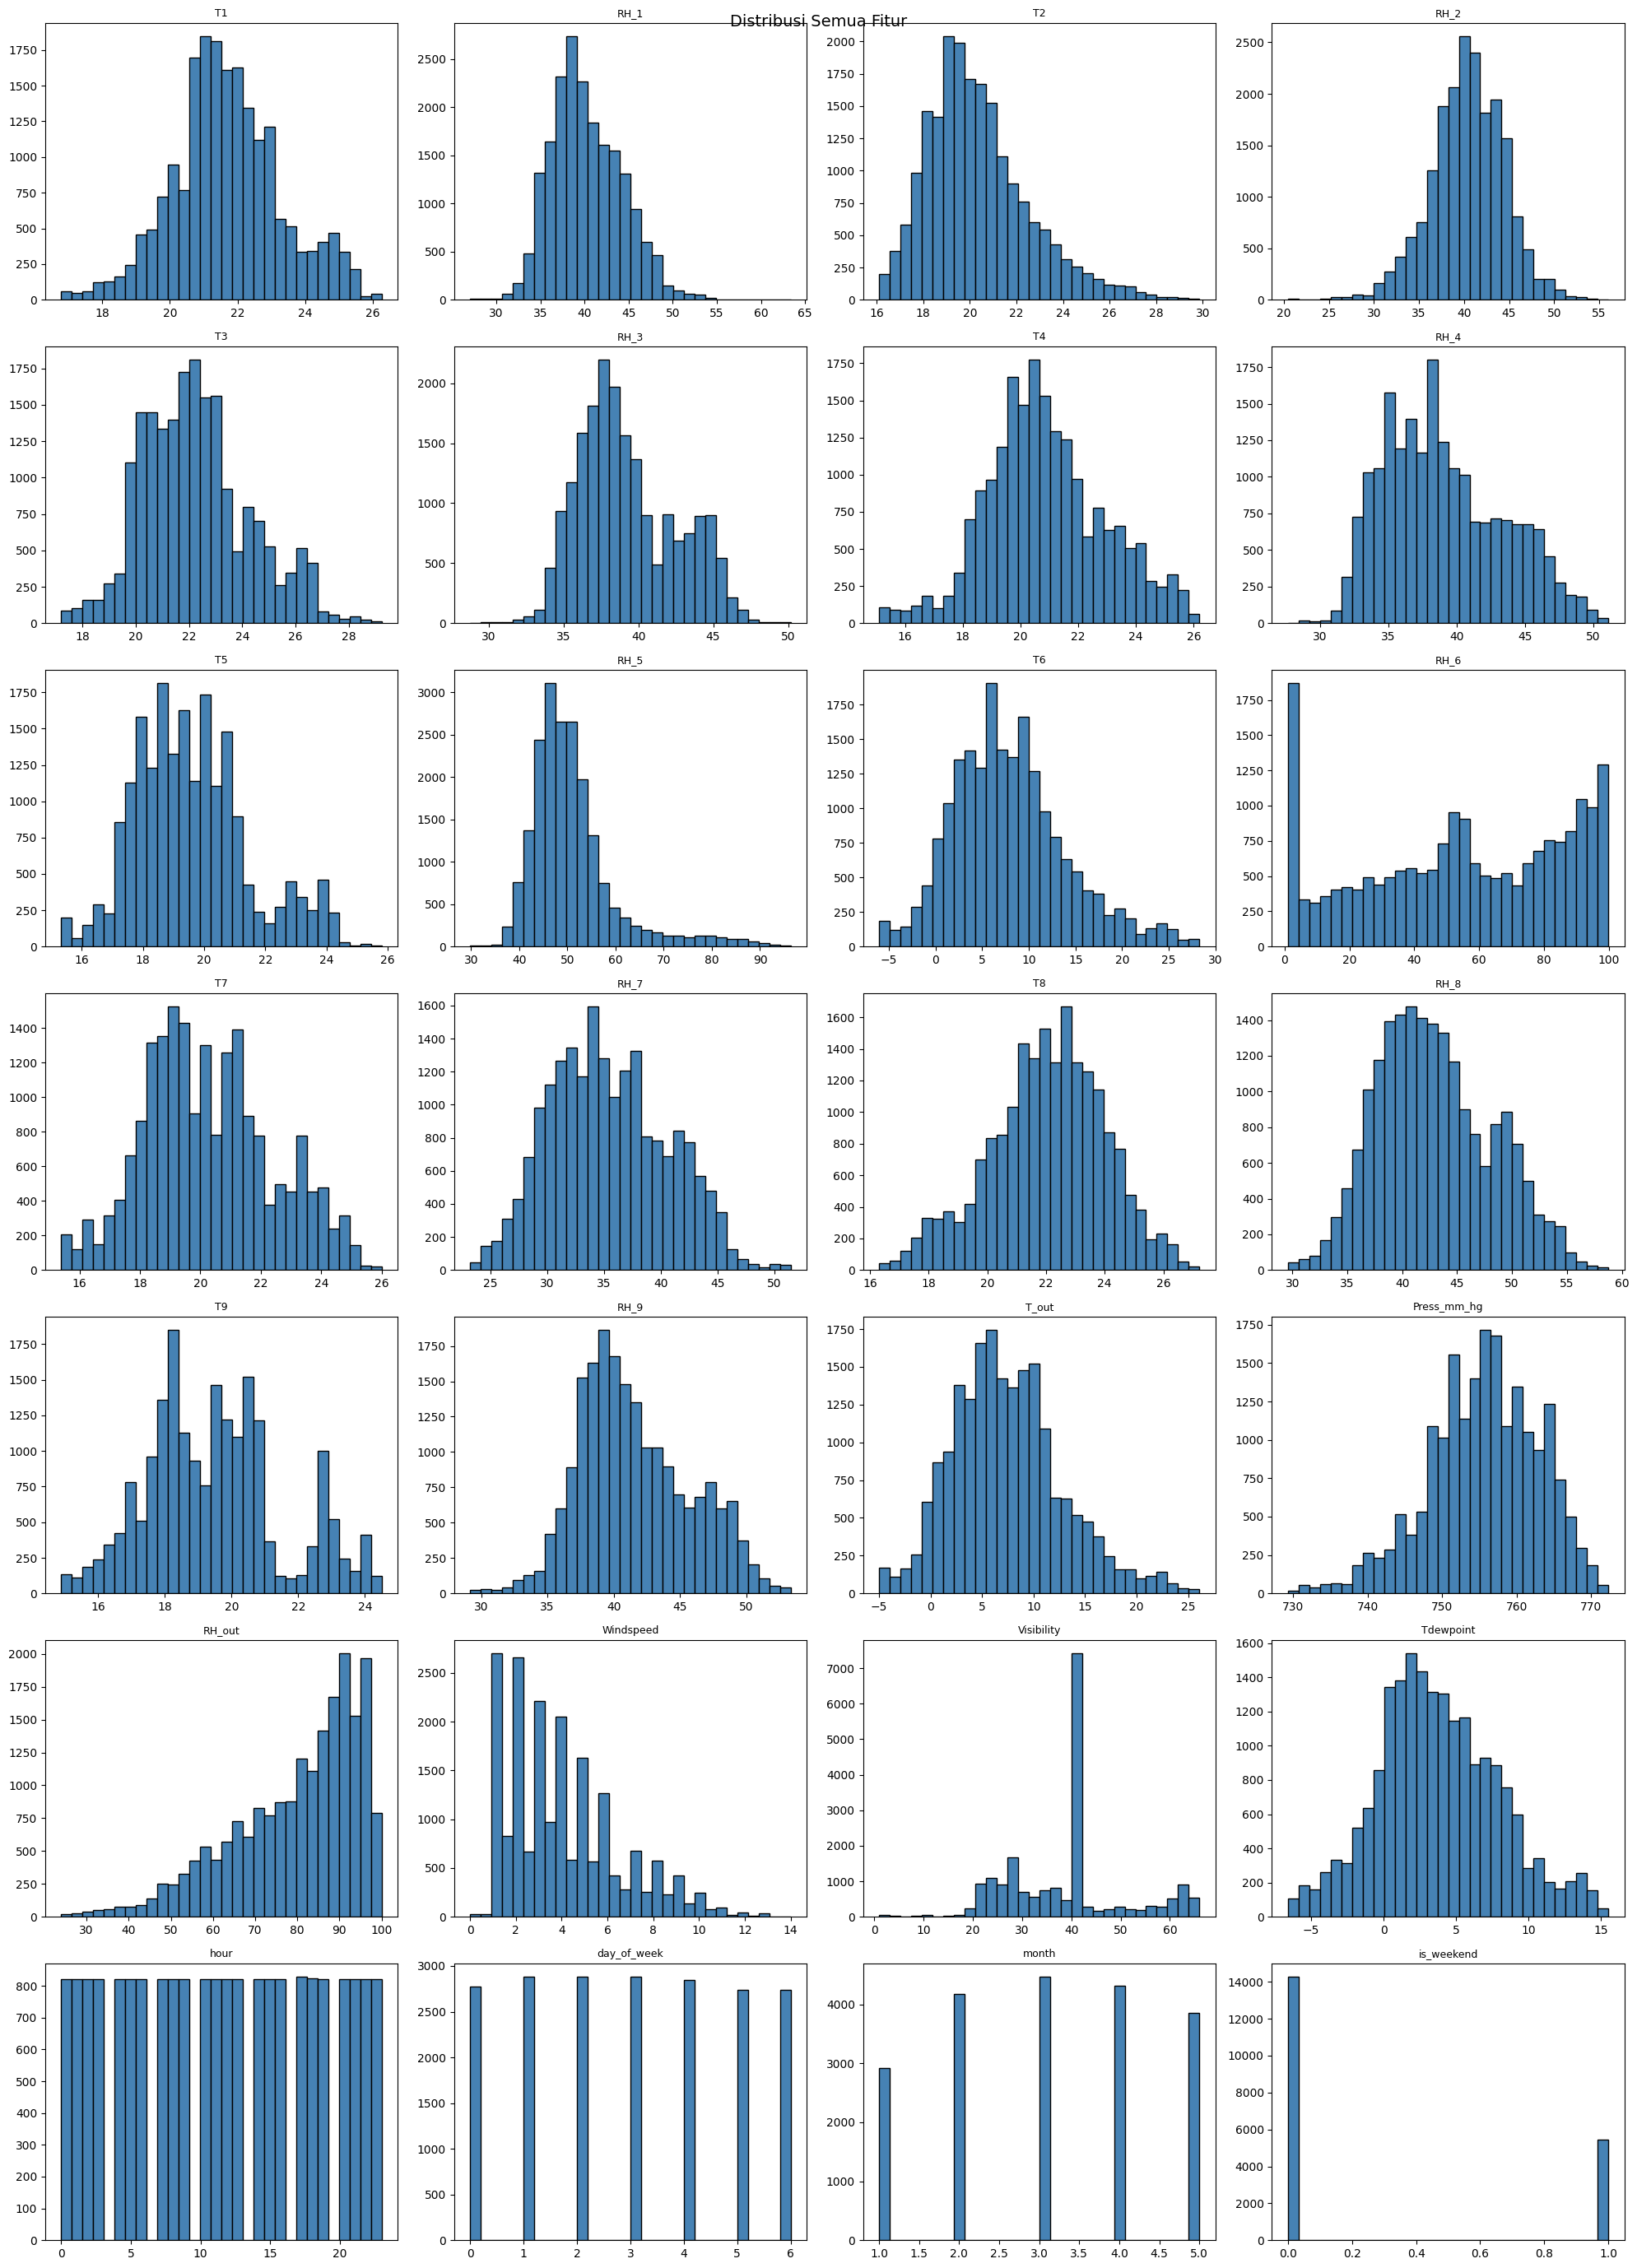

In [4]:
cols_to_plot = [c for c in df.columns if c != 'energy_total']
n_cols = 4
n_rows = int(np.ceil(len(cols_to_plot) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(col, fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Semua Fitur', fontsize=14)
plt.tight_layout()
plt.savefig('energy_dist_plot.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Distribusi Target (energy_total)

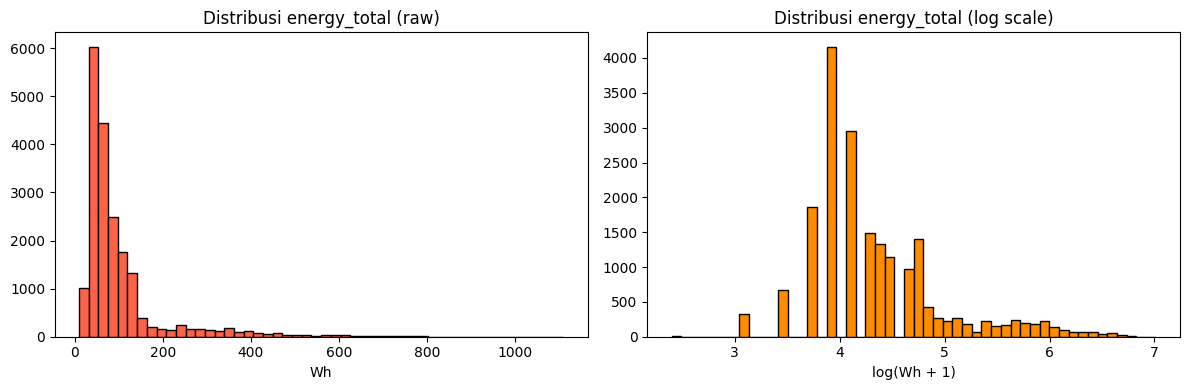

Statistik target:
count    19735.000000
mean       101.496833
std        104.380829
min         10.000000
25%         50.000000
50%         60.000000
75%        100.000000
max       1110.000000
Name: energy_total, dtype: float64

Skewness: 3.3030


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['energy_total'], bins=50, color='tomato', edgecolor='black')
axes[0].set_title('Distribusi energy_total (raw)')
axes[0].set_xlabel('Wh')

axes[1].hist(np.log1p(df['energy_total']), bins=50, color='darkorange', edgecolor='black')
axes[1].set_title('Distribusi energy_total (log scale)')
axes[1].set_xlabel('log(Wh + 1)')

plt.tight_layout()
plt.savefig('energy_target_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print("Statistik target:")
print(df['energy_total'].describe())
print(f"\nSkewness: {df['energy_total'].skew():.4f}")

### 4.3 Outlier Handling

Outlier pada target `energy_total` dihapus menggunakan metode IQR (batas 1.5x IQR dari Q1 dan Q3).
Fitur prediktor tidak difilter karena nilai ekstrem suhu dan kelembaban dapat merepresentasikan
kondisi musiman yang valid secara fisis.

In [6]:
Q1  = df['energy_total'].quantile(0.25)
Q3  = df['energy_total'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean = df[(df['energy_total'] >= lower) & (df['energy_total'] <= upper)].copy()

print(f"Shape sebelum outlier removal : {df.shape}")
print(f"Shape setelah outlier removal : {df_clean.shape}")
print(f"Jumlah baris dihapus          : {df.shape[0] - df_clean.shape[0]}")
print(f"Batas bawah                   : {lower:.2f} Wh")
print(f"Batas atas                    : {upper:.2f} Wh")
print(f"\nStatistik target setelah cleaning:")
print(df_clean['energy_total'].describe())

df = df_clean.copy()

Shape sebelum outlier removal : (19735, 29)
Shape setelah outlier removal : (17525, 29)
Jumlah baris dihapus          : 2210
Batas bawah                   : -25.00 Wh
Batas atas                    : 175.00 Wh

Statistik target setelah cleaning:
count    17525.000000
mean        70.165478
std         30.699187
min         10.000000
25%         50.000000
50%         60.000000
75%         90.000000
max        170.000000
Name: energy_total, dtype: float64


### 4.4 Heatmap Korelasi Antar Fitur

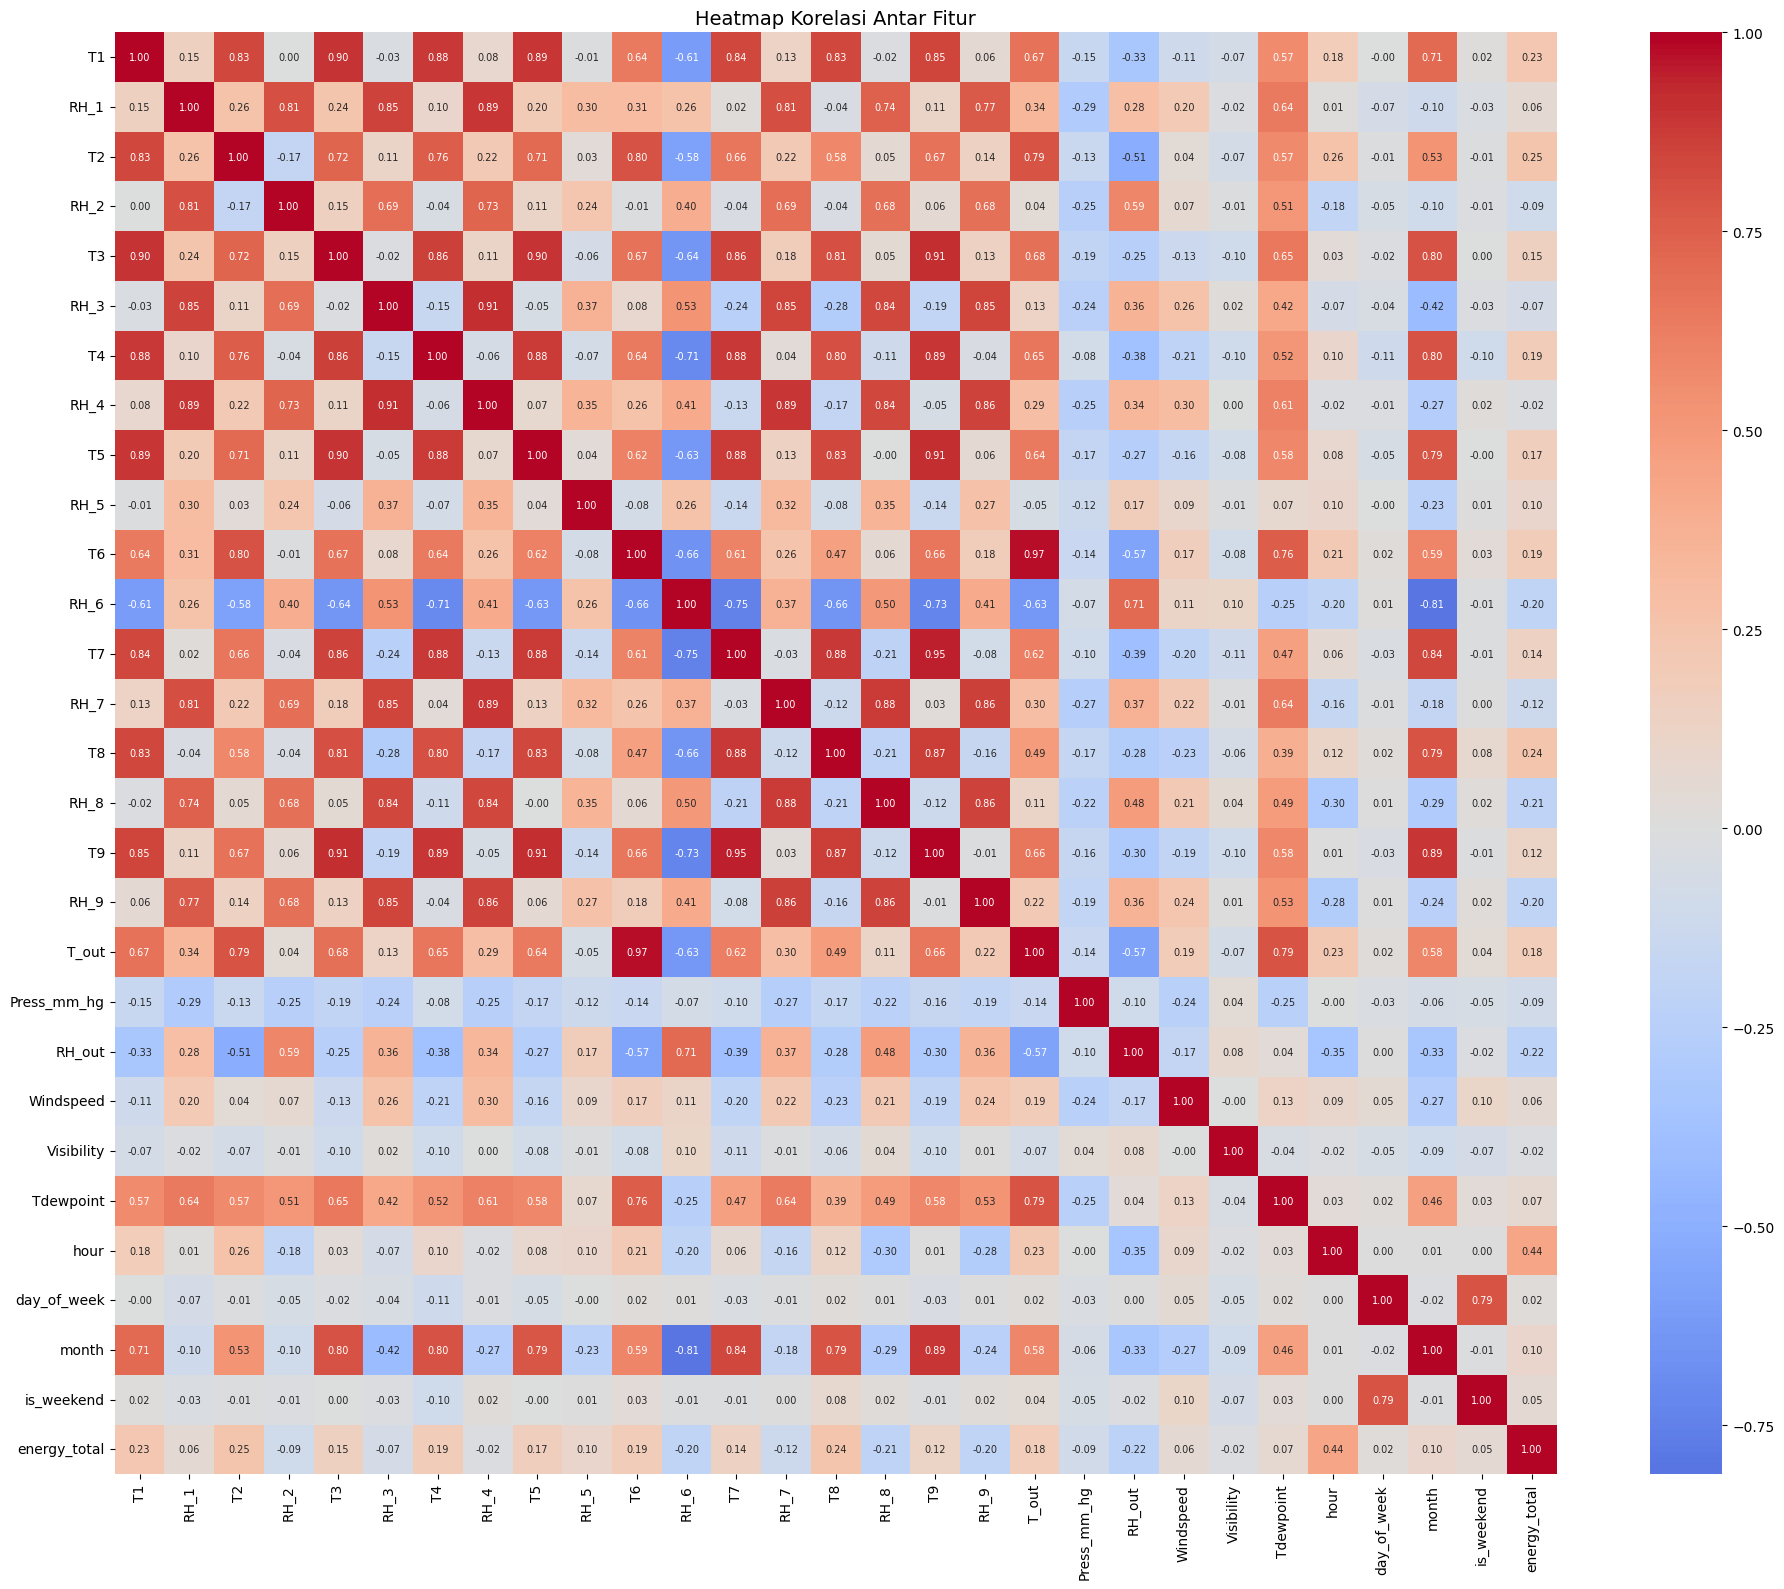

Korelasi fitur terhadap target (energy_total):
energy_total    1.000
hour            0.441
T2              0.247
T8              0.243
T1              0.233
T6              0.192
T4              0.187
T_out           0.184
T5              0.169
T3              0.151
T7              0.142
T9              0.118
RH_5            0.099
month           0.099
Tdewpoint       0.068
RH_1            0.058
Windspeed       0.058
is_weekend      0.055
day_of_week     0.018
RH_4           -0.017
Visibility     -0.020
RH_3           -0.067
Press_mm_hg    -0.088
RH_2           -0.093
RH_7           -0.118
RH_9           -0.198
RH_6           -0.198
RH_8           -0.207
RH_out         -0.222
Name: energy_total, dtype: float64


In [7]:
plt.figure(figsize=(20, 16))
corr_matrix = df.corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    annot_kws={'size': 7}
)
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14)
plt.tight_layout()
plt.savefig('energy_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Korelasi fitur terhadap target (energy_total):")
print(corr_matrix['energy_total'].sort_values(ascending=False).round(3))

---
## 5. Preprocessing

### 5.1 Standardisasi (StandardScaler)

StandardScaler digunakan karena SVR sangat sensitif terhadap perbedaan skala fitur.
Linear Regression juga mendapat manfaat dari scaling untuk stabilitas numerik.

In [8]:
X = df.drop(columns=['energy_total']).reset_index(drop=True)
y = df['energy_total'].reset_index(drop=True)

scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("Shape X_scaled:", X_scaled.shape)
print("\nVerifikasi scaling (mean ~0, std ~1):")
print(X_scaled.describe().loc[['mean', 'std']].round(3))

Shape X_scaled: (17525, 28)

Verifikasi scaling (mean ~0, std ~1):
       T1  RH_1   T2  RH_2   T3  RH_3   T4  RH_4   T5  RH_5  ...  T_out  \
mean  0.0   0.0 -0.0   0.0  0.0   0.0  0.0  -0.0  0.0   0.0  ...    0.0   
std   1.0   1.0  1.0   1.0  1.0   1.0  1.0   1.0  1.0   1.0  ...    1.0   

      Press_mm_hg  RH_out  Windspeed  Visibility  Tdewpoint  hour  \
mean          0.0     0.0       -0.0        -0.0        0.0  -0.0   
std           1.0     1.0        1.0         1.0        1.0   1.0   

      day_of_week  month  is_weekend  
mean         -0.0   -0.0        -0.0  
std           1.0    1.0         1.0  

[2 rows x 28 columns]


### 5.2 Feature Selection (SelectKBest — f_regression)

`f_regression` mengukur korelasi linear antara tiap fitur dan target regresi.
Fitur dengan F-score tinggi memiliki hubungan linear yang lebih kuat dengan `energy_total`.

F-Score semua fitur:
        feature    f_score  p_value
0          hour  4228.0510   0.0000
1            T2  1134.6574   0.0000
2            T8  1102.8973   0.0000
3            T1  1003.3577   0.0000
4        RH_out   907.0897   0.0000
5          RH_8   783.9725   0.0000
6          RH_6   715.0544   0.0000
7          RH_9   713.4715   0.0000
8            T6   672.7703   0.0000
9            T4   633.1933   0.0000
10        T_out   611.4640   0.0000
11           T5   514.3213   0.0000
12           T3   408.7454   0.0000
13           T7   360.0604   0.0000
14         RH_7   248.5725   0.0000
15           T9   247.7509   0.0000
16         RH_5   173.4155   0.0000
17        month   173.3951   0.0000
18         RH_2   152.7438   0.0000
19  Press_mm_hg   137.3156   0.0000
20    Tdewpoint    81.4757   0.0000
21         RH_3    77.8638   0.0000
22         RH_1    59.1541   0.0000
23    Windspeed    58.8202   0.0000
24   is_weekend    52.2889   0.0000
25   Visibility     7.0771   0.0078
26  day

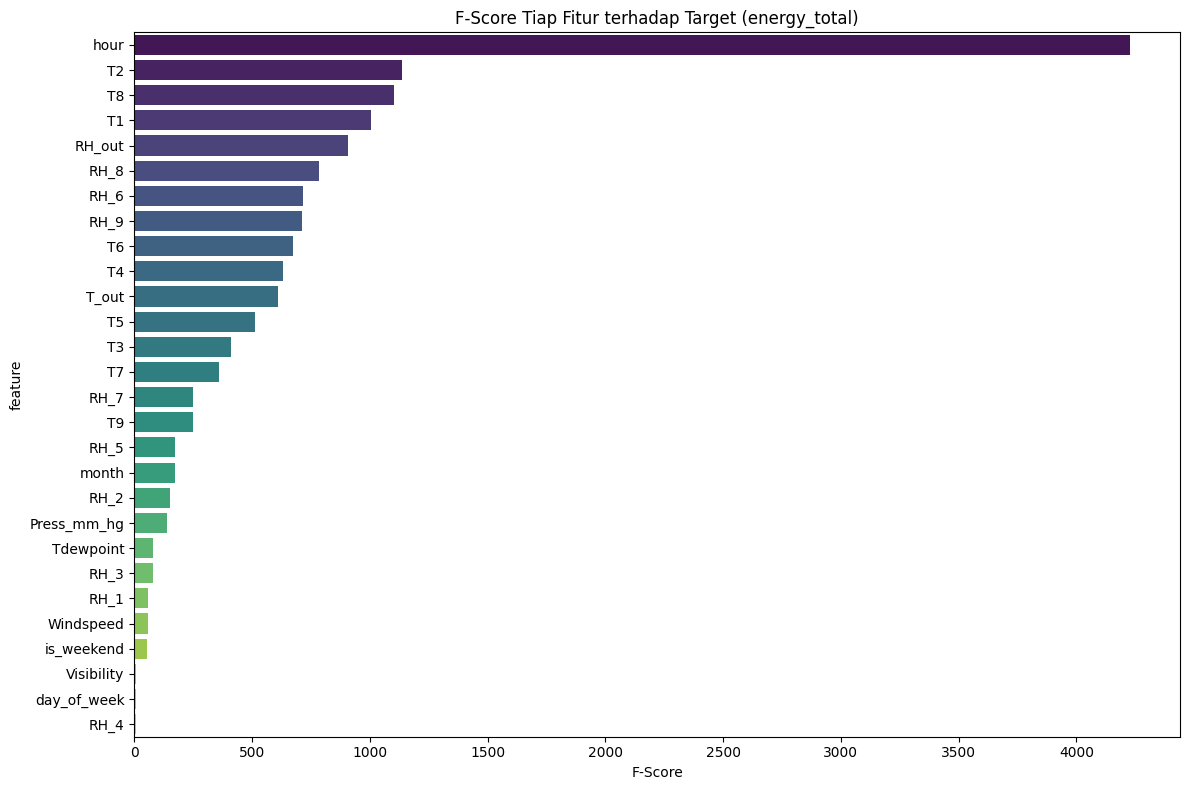

In [9]:
selector_all = SelectKBest(score_func=f_regression, k='all')
selector_all.fit(X_scaled, y)

feature_scores = pd.DataFrame({
    'feature': X.columns,
    'f_score': selector_all.scores_,
    'p_value': selector_all.pvalues_
}).sort_values('f_score', ascending=False).reset_index(drop=True)

print("F-Score semua fitur:")
print(feature_scores.round(4).to_string())

plt.figure(figsize=(12, 8))
sns.barplot(data=feature_scores, x='f_score', y='feature', palette='viridis')
plt.title('F-Score Tiap Fitur terhadap Target (energy_total)')
plt.xlabel('F-Score')
plt.tight_layout()
plt.savefig('energy_feature_scores.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
k_best     = 15
selector_k = SelectKBest(score_func=f_regression, k=k_best)
X_selected = pd.DataFrame(
    selector_k.fit_transform(X_scaled, y),
    columns=X.columns[selector_k.get_support()].tolist()
)

print(f"Fitur terpilih (top {k_best}):")
print(X_selected.columns.tolist())
print(f"\nShape setelah feature selection: {X_selected.shape}")

Fitur terpilih (top 15):
['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'RH_9', 'T_out', 'RH_out', 'hour']

Shape setelah feature selection: (17525, 15)


---
## 6. Baseline Model

### 6.1 Definisi Model dan Fungsi Evaluasi

Model yang dievaluasi:
- **Linear Regression** — model regresi linear klasik, interpretabel
- **SVR** (Support Vector Regression, kernel RBF) — model non-linear berbasis margin

Metrik evaluasi: MAE, MSE, RMSE, R2, CV R2 (k=5, KFold)

In [11]:
splits = {'80:20': 0.2, '70:30': 0.3}


def get_models():
    return {
        'Linear Regression': LinearRegression(),
        'SVR'              : SVR(kernel='rbf')
    }


def evaluate_regression(name, model, X_tr, X_te, y_tr, y_te, cv_folds=5):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    mae  = mean_absolute_error(y_te, y_pred)
    mse  = mean_squared_error(y_te, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_te, y_pred)

    cv        = KFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='r2', n_jobs=-1)

    return {
        'Model'     : name,
        'MAE'       : round(mae,  4),
        'MSE'       : round(mse,  4),
        'RMSE'      : round(rmse, 4),
        'R2'        : round(r2,   4),
        'CV R2 Mean': round(cv_scores.mean(), 4),
        'CV R2 Std' : round(cv_scores.std(),  4),
        'y_pred'    : y_pred
    }


print("Model dan fungsi evaluasi siap.")

Model dan fungsi evaluasi siap.


### 6.2 Baseline Sebelum Feature Selection

In [12]:
print("=" * 65)
print("BASELINE SEBELUM FEATURE SELECTION")
print("=" * 65)

results_before = {}

for split_name, test_size in splits.items():
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y, test_size=test_size, random_state=RANDOM_STATE
    )
    split_results = []
    for name, model in get_models().items():
        print(f"  Training {name} | Split {split_name}...")
        result = evaluate_regression(name, model, X_tr, X_te, y_tr, y_te)
        result.pop('y_pred')
        result['Split'] = split_name
        split_results.append(result)

    results_before[split_name] = pd.DataFrame(split_results)
    print(f"\n  Hasil Split {split_name} (Sebelum FS):")
    print(results_before[split_name].set_index('Model').drop(columns='Split').to_string())
    print()

BASELINE SEBELUM FEATURE SELECTION
  Training Linear Regression | Split 80:20...
  Training SVR | Split 80:20...

  Hasil Split 80:20 (Sebelum FS):
                       MAE       MSE     RMSE      R2  CV R2 Mean  CV R2 Std
Model                                                                       
Linear Regression  18.6496  611.5969  24.7305  0.3525      0.3520     0.0166
SVR                17.2488  587.6248  24.2410  0.3778      0.3614     0.0123

  Training Linear Regression | Split 70:30...
  Training SVR | Split 70:30...

  Hasil Split 70:30 (Sebelum FS):
                       MAE       MSE     RMSE      R2  CV R2 Mean  CV R2 Std
Model                                                                       
Linear Regression  18.5295  609.1702  24.6814  0.3586      0.3503     0.0125
SVR                17.4278  600.4276  24.5036  0.3678      0.3488     0.0107



### 6.3 Baseline Sesudah Feature Selection

In [13]:
print("=" * 65)
print("BASELINE SESUDAH FEATURE SELECTION")
print("=" * 65)

results_after = {}
predictions   = {}

for split_name, test_size in splits.items():
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_selected, y, test_size=test_size, random_state=RANDOM_STATE
    )
    split_results = []
    split_preds   = {}

    for name, model in get_models().items():
        print(f"  Training {name} | Split {split_name}...")
        result = evaluate_regression(name, model, X_tr, X_te, y_tr, y_te)
        split_preds[name] = {
            'y_te'  : y_te.values,
            'y_pred': result.pop('y_pred')
        }
        result['Split'] = split_name
        split_results.append(result)

    results_after[split_name] = pd.DataFrame(split_results)
    predictions[split_name]   = split_preds

    print(f"\n  Hasil Split {split_name} (Sesudah FS):")
    print(results_after[split_name].set_index('Model').drop(columns='Split').to_string())
    print()

BASELINE SESUDAH FEATURE SELECTION
  Training Linear Regression | Split 80:20...
  Training SVR | Split 80:20...

  Hasil Split 80:20 (Sesudah FS):
                       MAE       MSE     RMSE      R2  CV R2 Mean  CV R2 Std
Model                                                                       
Linear Regression  19.4150  669.8598  25.8816  0.2908      0.2791     0.0121
SVR                17.5296  601.4674  24.5248  0.3632      0.3404     0.0085

  Training Linear Regression | Split 70:30...
  Training SVR | Split 70:30...

  Hasil Split 70:30 (Sesudah FS):
                       MAE       MSE     RMSE      R2  CV R2 Mean  CV R2 Std
Model                                                                       
Linear Regression  19.3432  671.6361  25.9159  0.2929      0.2770     0.0191
SVR                17.7304  618.2525  24.8647  0.3491      0.3305     0.0116



### 6.4 Perbandingan Before vs After Feature Selection

In [14]:
print("=" * 75)
print("PERBANDINGAN BEFORE VS AFTER FEATURE SELECTION")
print("=" * 75)

for split_name in splits.keys():
    df_b = results_before[split_name].set_index('Model').drop(columns='Split')
    df_a = results_after[split_name].set_index('Model').drop(columns='Split')

    print(f"\nSplit {split_name}:")
    print(f"{'Model':<22} {'Stage':<8} {'MAE':>8} {'RMSE':>8} {'R2':>8} {'CV R2':>8}")
    print("-" * 62)

    for model_name in df_b.index:
        b = df_b.loc[model_name]
        a = df_a.loc[model_name]
        print(f"{model_name:<22} {'Before':<8} {b['MAE']:>8.4f} {b['RMSE']:>8.4f} {b['R2']:>8.4f} {b['CV R2 Mean']:>8.4f}")
        print(f"{'': <22} {'After':<8} {a['MAE']:>8.4f} {a['RMSE']:>8.4f} {a['R2']:>8.4f} {a['CV R2 Mean']:>8.4f}")
        print()

PERBANDINGAN BEFORE VS AFTER FEATURE SELECTION

Split 80:20:
Model                  Stage         MAE     RMSE       R2    CV R2
--------------------------------------------------------------
Linear Regression      Before    18.6496  24.7305   0.3525   0.3520
                       After     19.4150  25.8816   0.2908   0.2791

SVR                    Before    17.2488  24.2410   0.3778   0.3614
                       After     17.5296  24.5248   0.3632   0.3404


Split 70:30:
Model                  Stage         MAE     RMSE       R2    CV R2
--------------------------------------------------------------
Linear Regression      Before    18.5295  24.6814   0.3586   0.3503
                       After     19.3432  25.9159   0.2929   0.2770

SVR                    Before    17.4278  24.5036   0.3678   0.3488
                       After     17.7304  24.8647   0.3491   0.3305



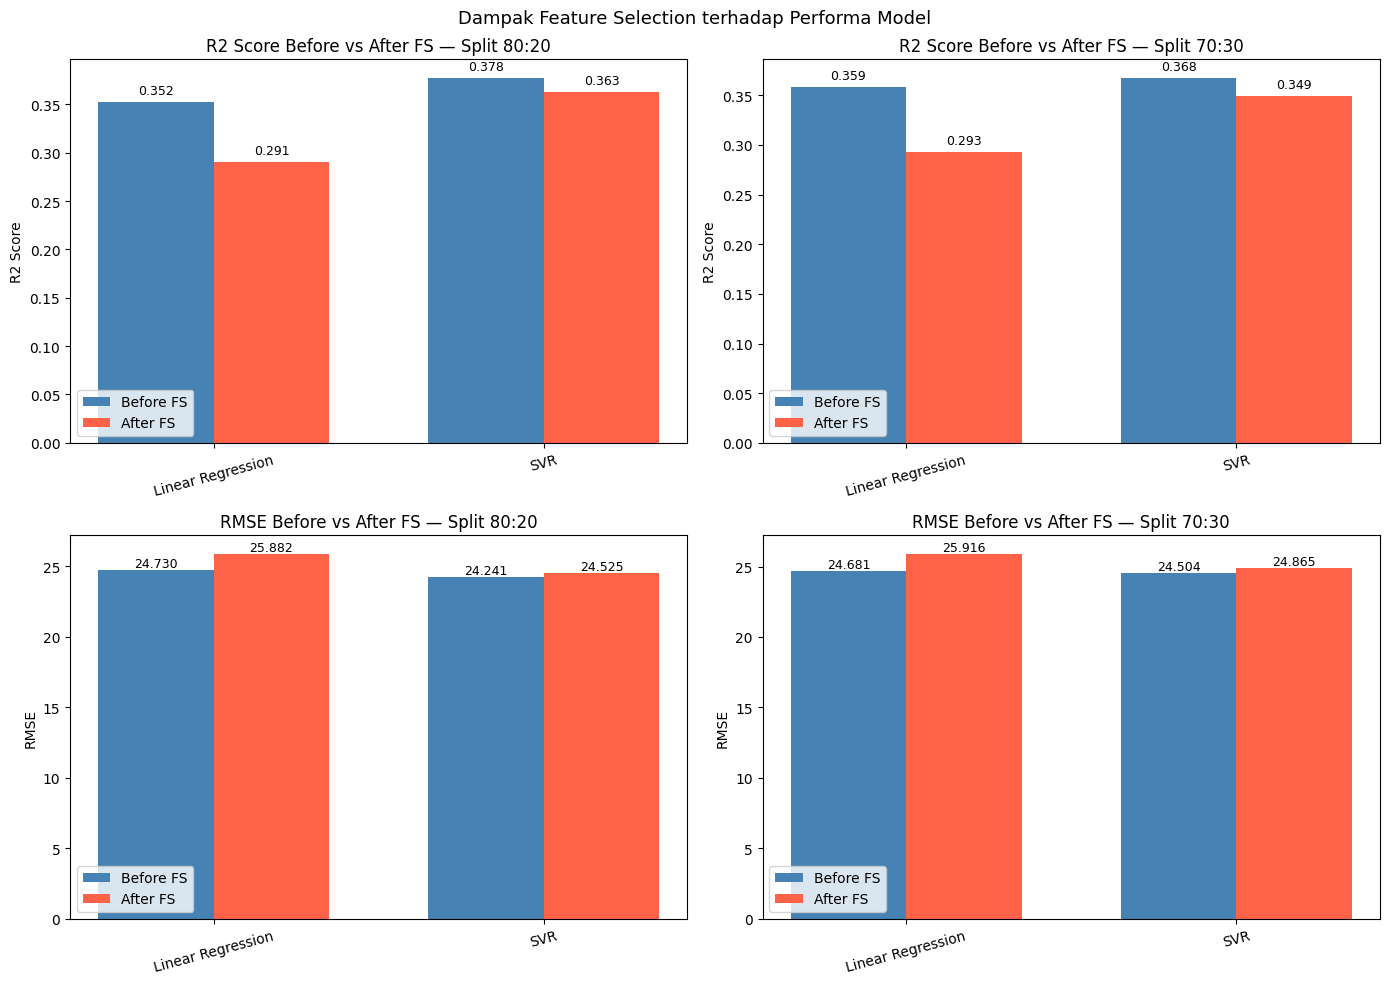

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics_to_plot = [('R2', 'R2 Score'), ('RMSE', 'RMSE')]

for row, (metric, metric_label) in enumerate(metrics_to_plot):
    for col, split_name in enumerate(splits.keys()):
        ax    = axes[row, col]
        df_b  = results_before[split_name]
        df_a  = results_after[split_name]
        x     = np.arange(len(df_b))
        width = 0.35

        bars1 = ax.bar(x - width/2, df_b[metric], width, label='Before FS', color='steelblue')
        bars2 = ax.bar(x + width/2, df_a[metric], width, label='After FS',  color='tomato')

        ax.set_xticks(x)
        ax.set_xticklabels(df_b['Model'], rotation=15)
        ax.set_title(f'{metric_label} Before vs After FS — Split {split_name}')
        ax.set_ylabel(metric_label)
        ax.legend()

        for bar in bars1:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
        for bar in bars2:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Dampak Feature Selection terhadap Performa Model', fontsize=13)
plt.tight_layout()
plt.savefig('energy_before_after_fs.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Hyperparameter Tuning

Model terbaik dipilih berdasarkan R2 dan RMSE dari hasil baseline di kedua split.

Strategi tuning:
- **Linear Regression**: tidak memiliki hyperparameter yang berpengaruh signifikan; digunakan
  sebagai pembanding. GridSearchCV tetap dijalankan untuk konsistensi alur eksperimen.
- **SVR**: RandomizedSearchCV dengan 16 iterasi, karena ruang parameter SVR luas
  (C, epsilon, kernel) sehingga random search lebih efisien daripada grid exhaustive.

Tuning dijalankan terpisah per split untuk menghindari bias parameter dari satu distribusi data.

In [16]:
param_grid_lr = {
    'fit_intercept': [True, False]
}

param_dist_svr = {
    'C'      : [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.5, 1.0],
    'kernel' : ['rbf', 'linear']
}

lr_tuned_per_split  = {}
svr_tuned_per_split = {}

for split_name, test_size in splits.items():
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y, test_size=test_size, random_state=RANDOM_STATE
    )

    print(f"Tuning Linear Regression | Split {split_name}...")
    lr_gs = GridSearchCV(
        LinearRegression(), param_grid_lr,
        cv=5, scoring='r2', n_jobs=-1, verbose=0
    )
    lr_gs.fit(X_tr, y_tr)
    lr_tuned_per_split[split_name] = lr_gs
    print(f"  Best params : {lr_gs.best_params_}")
    print(f"  Best CV R2  : {lr_gs.best_score_:.4f}")

    print(f"Tuning SVR (RandomizedSearchCV) | Split {split_name}...")
    svr_rs = RandomizedSearchCV(
        SVR(), param_dist_svr,
        n_iter=16, cv=5, scoring='r2',
        random_state=RANDOM_STATE, n_jobs=-1, verbose=0
    )
    svr_rs.fit(X_tr, y_tr)
    svr_tuned_per_split[split_name] = svr_rs
    print(f"  Best params : {svr_rs.best_params_}")
    print(f"  Best CV R2  : {svr_rs.best_score_:.4f}")
    print()

Tuning Linear Regression | Split 80:20...
  Best params : {'fit_intercept': True}
  Best CV R2  : 0.3526
Tuning SVR (RandomizedSearchCV) | Split 80:20...
  Best params : {'kernel': 'rbf', 'epsilon': 1.0, 'C': 100}
  Best CV R2  : 0.6110

Tuning Linear Regression | Split 70:30...
  Best params : {'fit_intercept': True}
  Best CV R2  : 0.3489
Tuning SVR (RandomizedSearchCV) | Split 70:30...
  Best params : {'kernel': 'rbf', 'epsilon': 1.0, 'C': 100}
  Best CV R2  : 0.6081



### 7.1 Perbandingan Sebelum vs Sesudah Tuning (Kedua Split)

In [17]:
print("=" * 65)
print("PERBANDINGAN SEBELUM VS SESUDAH TUNING")
print("=" * 65)

tuning_results = {}

for split_name, test_size in splits.items():
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y, test_size=test_size, random_state=RANDOM_STATE
    )

    tuned_models = {
        'Linear Regression': (LinearRegression(),  lr_tuned_per_split[split_name].best_estimator_),
        'SVR'              : (SVR(kernel='rbf'),    svr_tuned_per_split[split_name].best_estimator_)
    }

    rows = []
    for model_name, (model_before, model_after) in tuned_models.items():
        for stage, model in [('Before', model_before), ('After', model_after)]:
            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_te)
            rows.append({
                'Model': model_name,
                'Stage': stage,
                'MAE'  : round(mean_absolute_error(y_te, y_pred), 4),
                'RMSE' : round(np.sqrt(mean_squared_error(y_te, y_pred)), 4),
                'R2'   : round(r2_score(y_te, y_pred), 4),
            })

    tuning_results[split_name] = pd.DataFrame(rows)

    print(f"\nSplit {split_name}:")
    print(f"{'Model':<22} {'Stage':<8} {'MAE':>8} {'RMSE':>8} {'R2':>8}")
    print("-" * 55)
    for _, row in tuning_results[split_name].iterrows():
        print(f"{row['Model']:<22} {row['Stage']:<8} {row['MAE']:>8.4f} {row['RMSE']:>8.4f} {row['R2']:>8.4f}")
    print()

PERBANDINGAN SEBELUM VS SESUDAH TUNING

Split 80:20:
Model                  Stage         MAE     RMSE       R2
-------------------------------------------------------
Linear Regression      Before    18.6496  24.7305   0.3525
Linear Regression      After     18.6496  24.7305   0.3525
SVR                    Before    17.2488  24.2410   0.3778
SVR                    After     12.5513  18.2933   0.6457


Split 70:30:
Model                  Stage         MAE     RMSE       R2
-------------------------------------------------------
Linear Regression      Before    18.5295  24.6814   0.3586
Linear Regression      After     18.5295  24.6814   0.3586
SVR                    Before    17.4278  24.5036   0.3678
SVR                    After     12.9463  18.8350   0.6265



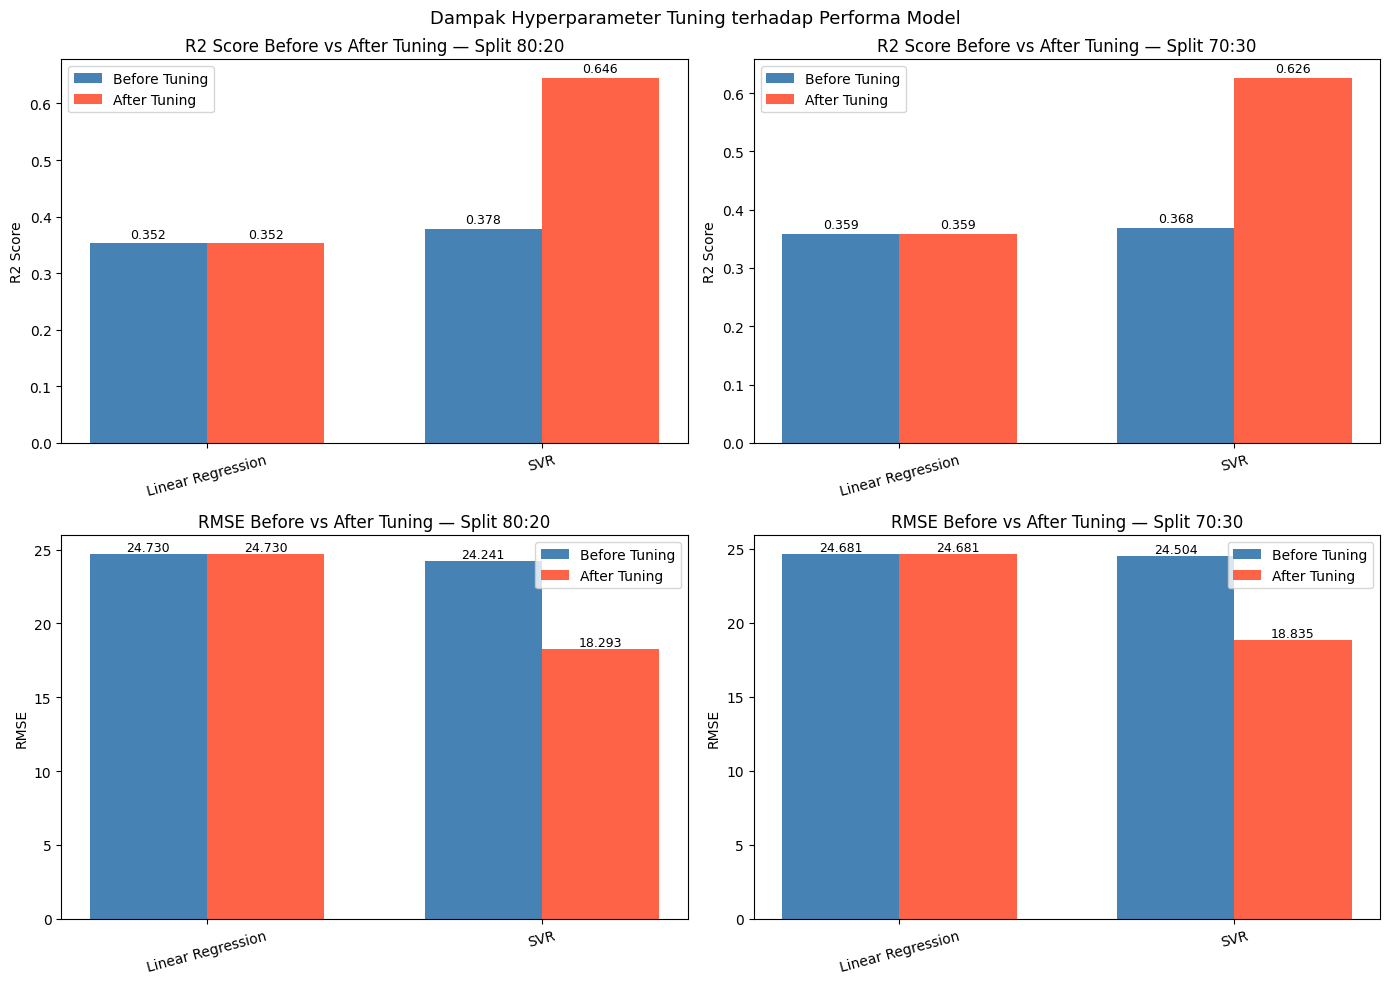

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, (metric, metric_label) in enumerate([('R2', 'R2 Score'), ('RMSE', 'RMSE')]):
    for col, split_name in enumerate(splits.keys()):
        ax          = axes[row, col]
        df_         = tuning_results[split_name]
        model_names = df_['Model'].unique()
        x           = np.arange(len(model_names))
        width       = 0.35

        before_vals = df_[df_['Stage'] == 'Before'][metric].values
        after_vals  = df_[df_['Stage'] == 'After'][metric].values

        bars1 = ax.bar(x - width/2, before_vals, width, label='Before Tuning', color='steelblue')
        bars2 = ax.bar(x + width/2, after_vals,  width, label='After Tuning',  color='tomato')

        ax.set_xticks(x)
        ax.set_xticklabels(model_names, rotation=15)
        ax.set_title(f'{metric_label} Before vs After Tuning — Split {split_name}')
        ax.set_ylabel(metric_label)
        ax.legend()

        for bar in bars1:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
        for bar in bars2:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Dampak Hyperparameter Tuning terhadap Performa Model', fontsize=13)
plt.tight_layout()
plt.savefig('energy_tuning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Visualisasi Error Plot — Model Terbaik

Visualisasi dilakukan untuk model terbaik (SVR Tuned) pada kedua split: 80:20 dan 70:30.

- **Actual vs Predicted**: ideal jika titik-titik mengikuti garis diagonal `y = x`. Penyimpangan dari garis ini menunjukkan besarnya error prediksi.
- **Residual Plot**: ideal jika residual tersebar acak di sekitar nol tanpa pola sistematis. Pola tertentu (kurva, corong) mengindikasikan adanya hubungan non-linear yang belum tertangkap model atau heteroskedastisitas.

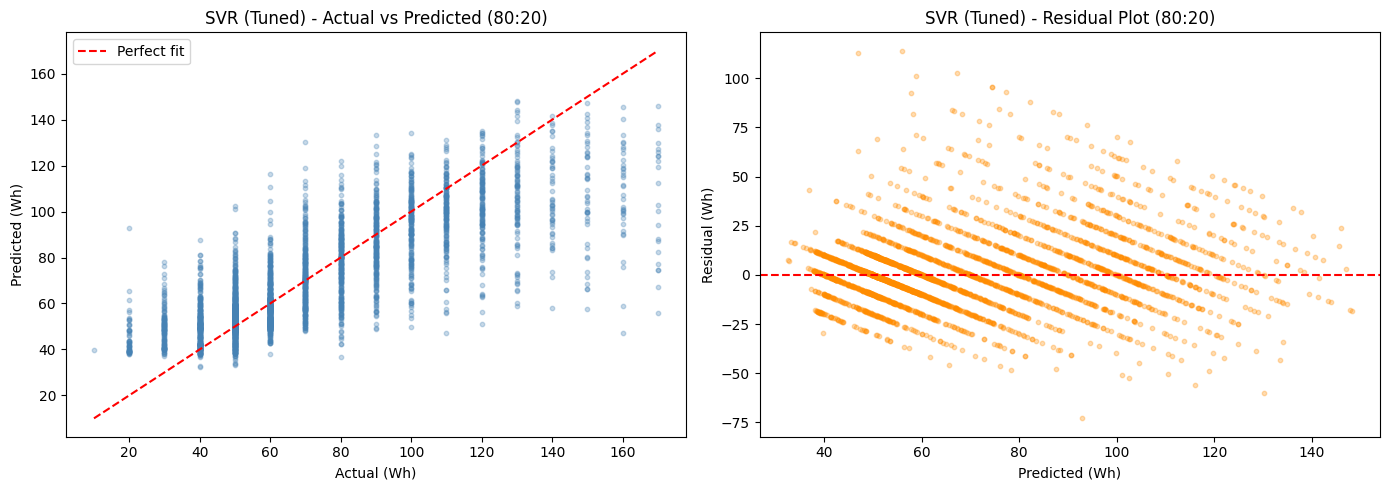

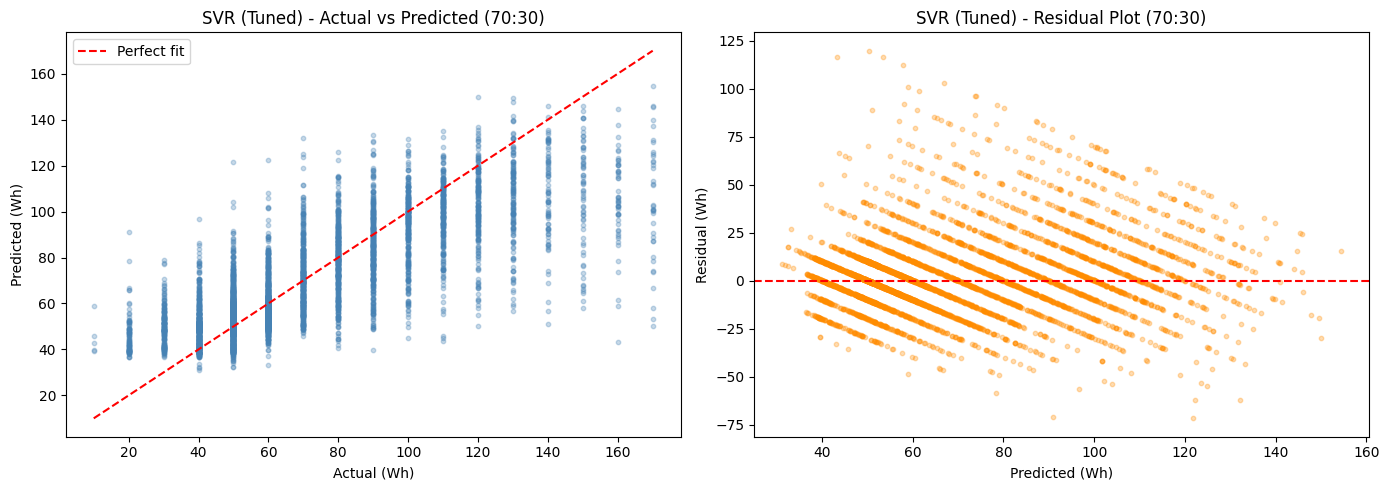

In [19]:
for split_name, test_size in splits.items():
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y, test_size=test_size, random_state=RANDOM_STATE
    )

    best_model = svr_tuned_per_split[split_name].best_estimator_
    best_model.fit(X_tr, y_tr)
    y_pred_best = best_model.predict(X_te)
    residuals   = y_te.values - y_pred_best

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(y_te, y_pred_best, alpha=0.3, s=10, color='steelblue')
    min_val = min(y_te.min(), y_pred_best.min())
    max_val = max(y_te.max(), y_pred_best.max())
    axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect fit')
    axes[0].set_xlabel('Actual (Wh)')
    axes[0].set_ylabel('Predicted (Wh)')
    axes[0].set_title(f'SVR (Tuned) - Actual vs Predicted ({split_name})')
    axes[0].legend()

    axes[1].scatter(y_pred_best, residuals, alpha=0.3, s=10, color='darkorange')
    axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
    axes[1].set_xlabel('Predicted (Wh)')
    axes[1].set_ylabel('Residual (Wh)')
    axes[1].set_title(f'SVR (Tuned) - Residual Plot ({split_name})')

    plt.tight_layout()
    plt.savefig(f'energy_error_plots_{split_name.replace(":", "_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

---
## 9. Summary Model Terbaik

In [20]:
print("=" * 60)
print("SUMMARY MODEL TERBAIK — SVR (TUNED)")
print("=" * 60)

for split_name in splits.keys():
    gs        = svr_tuned_per_split[split_name]
    df_       = tuning_results[split_name]
    svr_after = df_[(df_['Model'] == 'SVR') & (df_['Stage'] == 'After')].iloc[0]

    print(f"Split {split_name}:")
    print(f"  Best params  : {gs.best_params_}")
    print(f"  Best CV R2   : {gs.best_score_:.4f}")
    print(f"  MAE          : {svr_after['MAE']:.4f} Wh")
    print(f"  RMSE         : {svr_after['RMSE']:.4f} Wh")
    print(f"  R2           : {svr_after['R2']:.4f}")
    print()

SUMMARY MODEL TERBAIK — SVR (TUNED)
Split 80:20:
  Best params  : {'kernel': 'rbf', 'epsilon': 1.0, 'C': 100}
  Best CV R2   : 0.6110
  MAE          : 12.5513 Wh
  RMSE         : 18.2933 Wh
  R2           : 0.6457

Split 70:30:
  Best params  : {'kernel': 'rbf', 'epsilon': 1.0, 'C': 100}
  Best CV R2   : 0.6081
  MAE          : 12.9463 Wh
  RMSE         : 18.8350 Wh
  R2           : 0.6265

